## Load the Adjusted Price Dataset

Import the main stock price dataset and inspect its structure before cleaning.

In [4]:
import pandas as pd
df = pd.read_csv("adjprice.csv")
df

,Date,0111145D US Equity,0202445Q US Equity,0203524D US Equity,0226226D US Equity,0376152D US Equity,0440296D US Equity,0544749D US Equity,0574018D US Equity,0598884D US Equity,...,YNR US Equity,YRCW US Equity,YUM US Equity,YUMC US Equity,ZBH US Equity,ZETHQ US Equity,ZION US Equity,ZRN US Equity,ZTS US Equity,ZTS-W US Equity
0,19930907,13.2719,13.6829,8.4429,8.1042,11.000,57.3245,17.8887,6.8315,28.1246,...,NaN,144439.5121,NaN,NaN,NaN,6.875,7.1675,30.7970,NaN,NaN
1,19930908,13.3263,13.5315,8.2147,7.9590,11.000,57.2096,17.8064,6.8315,27.5051,...,NaN,143691.1208,NaN,NaN,NaN,6.750,6.9766,30.0188,NaN,NaN
2,19930909,13.7070,13.3800,8.7852,8.0627,11.125,59.1625,17.6831,6.8315,27.7529,...,NaN,143691.1208,NaN,NaN,NaN,6.625,6.9554,30.0188,NaN,NaN
3,19930910,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN
4,19930911,13.3807,13.4810,9.4127,8.0368,11.125,59.6220,17.6420,6.8773,27.5051,...,NaN,145187.9033,NaN,NaN,NaN,6.750,7.2099,29.6852,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9454,20190727,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.3500,114.02,45.31,134.50,NaN,45.1600,NaN,115.11,NaN
9455,20190728,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.3500,114.02,45.31,134.50,NaN,45.1600,NaN,115.11,NaN
9456,20190729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.1800,114.10,45.43,134.53,NaN,44.6500,NaN,115.55,NaN
9457,20190730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,3.1800,113.24,44.00,136.67,NaN,45.4800,NaN,115.79,NaN


## Filter Stocks by Data Coverage

Keep only stocks with sufficient historical data so the later return calculations are more reliable.

In [6]:
coverage = df.notna().mean()
df = df.loc[:, coverage >= 0.9]
df

,Date,1436513D US Equity,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
0,19930907,3.0147,13.6285,0.8044,NaN,3.750,3.2659,16.9898,2.3712,2.9608,...,6.7803,20.5434,6.9696,12.3149,2.5342,8.0198,5.3036,20.5503,144439.5121,7.1675
1,19930908,2.9691,13.3718,0.8197,NaN,4.375,3.2037,17.0863,2.4320,2.9025,...,6.6519,20.3829,6.9696,12.2506,2.4735,8.0815,5.1244,20.5503,143691.1208,6.9766
2,19930909,3.0278,13.4652,0.7967,NaN,4.375,3.2659,17.1828,2.3104,3.0046,...,6.5878,20.4632,6.9326,12.2506,2.5797,8.0044,5.1244,20.3040,143691.1208,6.9554
3,19930910,3.0278,13.3952,0.8044,NaN,4.125,3.2659,16.6036,2.3712,3.1067,...,6.6947,20.7039,7.0065,12.2506,2.7087,8.0969,5.3036,20.4096,145187.9033,7.2099
4,19930911,3.0278,13.3952,0.8044,NaN,4.125,3.2659,16.6036,2.3712,3.1067,...,6.6947,20.7039,7.0065,12.2506,2.7087,8.0969,5.3036,20.4096,145187.9033,7.2099
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9454,20190727,NaN,23.1300,207.7400,86.12,272.660,87.7500,NaN,311.2700,121.8000,...,26.2100,15.1900,60.5100,57.5900,120.7700,74.8100,56.0200,34.4300,3.3500,45.1600
9455,20190728,NaN,23.1300,207.7400,86.12,272.660,87.7500,NaN,311.2700,121.8000,...,26.2100,15.1900,60.5100,57.5900,120.7700,74.8100,56.0200,34.4300,3.3500,45.1600
9456,20190729,NaN,23.1200,209.6800,87.23,275.930,88.5500,NaN,307.2200,121.2100,...,25.8400,15.2700,60.9800,57.5900,120.5500,75.3400,56.3700,33.9400,3.1800,44.6500
9457,20190730,NaN,23.0400,208.7800,88.72,279.230,88.3100,NaN,303.6400,120.9600,...,26.0900,15.7100,60.5900,57.5900,119.5100,75.3500,56.6700,32.7800,3.1800,45.4800


## Remove Remaining Missing Values

Drop rows with missing values after the stock coverage filter has been applied.

In [8]:
df_clean = df.dropna()
df_clean

,Date,1436513D US Equity,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
904,19960228,3.9666,21.4810,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
905,19960229,4.0085,22.3658,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
906,19960301,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
907,19960302,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
908,19960303,3.9037,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,20160919,45.4500,20.9622,109.5665,80.0464,125.100,39.7491,16.9158,99.6800,59.8806,...,27.9673,16.5371,39.0638,32.4004,51.0060,76.8618,58.8778,24.0173,11.7500,28.9620
8414,20160920,45.4500,21.1414,109.5569,78.9119,125.100,39.6538,16.9256,100.6200,59.7655,...,27.8095,16.3699,38.9138,32.4390,50.4720,75.6790,58.7299,23.9198,11.6800,28.9329
8415,20160921,45.4500,21.6565,109.5376,79.8156,126.900,39.9780,18.3918,107.7800,60.6859,...,28.1623,17.6094,39.8792,33.1146,50.7771,76.3758,59.0454,24.2367,11.9000,29.0492
8416,20160922,45.4500,21.9028,110.5698,80.3636,126.370,40.2641,18.2344,107.9200,61.0502,...,29.7774,17.9046,40.2072,33.4813,50.9583,76.5959,59.1637,24.4074,12.2600,29.3301


## Remove Duplicate Trading Records and Non-Standard Columns

Remove repeated price rows and drop columns that should not be used as tradable stock assets.

In [10]:
df_cleaned = df_clean[~df_clean.iloc[:, 1:].duplicated()]
df_cleaned = df_cleaned.drop(df.columns[1], axis=1)
df_cleaned

,Date,AA US Equity,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
904,19960228,21.4810,0.8753,2.9793,6.063,5.4616,23.8016,4.1685,7.2854,9.5428,...,8.0538,23.0299,8.5667,19.6972,8.2626,10.7800,5.8269,40.5005,72042.1892,13.4914
905,19960229,22.3658,0.8674,2.9793,6.063,5.5111,23.6065,4.1377,7.0556,9.3605,...,7.8455,22.5986,8.4594,19.2825,7.0334,10.9522,5.7542,39.3304,71637.4578,13.4232
906,19960301,22.5133,0.8477,2.8766,6.438,5.5771,23.5089,4.0296,6.5634,9.4212,...,7.7761,22.6849,8.6096,19.3517,5.6905,10.9867,5.6453,39.1417,72042.1892,13.5142
909,19960304,22.8574,0.8280,2.9279,6.063,5.7916,22.5335,3.9987,6.4321,9.4212,...,8.1464,23.1162,8.6955,19.5936,5.2352,10.9350,5.7542,38.9530,71232.7264,13.5369
910,19960305,22.8082,0.8398,3.0050,6.063,5.7091,22.8261,4.0450,6.8259,9.2997,...,8.0538,23.0299,8.7170,19.6281,5.7588,11.1417,5.7542,39.7834,70423.2636,13.6052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8413,20160919,20.9622,109.5665,80.0464,125.100,39.7491,16.9158,99.6800,59.8806,39.4369,...,27.9673,16.5371,39.0638,32.4004,51.0060,76.8618,58.8778,24.0173,11.7500,28.9620
8414,20160920,21.1414,109.5569,78.9119,125.100,39.6538,16.9256,100.6200,59.7655,39.4089,...,27.8095,16.3699,38.9138,32.4390,50.4720,75.6790,58.7299,23.9198,11.6800,28.9329
8415,20160921,21.6565,109.5376,79.8156,126.900,39.9780,18.3918,107.7800,60.6859,40.0260,...,28.1623,17.6094,39.8792,33.1146,50.7771,76.3758,59.0454,24.2367,11.9000,29.0492
8416,20160922,21.9028,110.5698,80.3636,126.370,40.2641,18.2344,107.9200,61.0502,40.1849,...,29.7774,17.9046,40.2072,33.4813,50.9583,76.5959,59.1637,24.4074,12.2600,29.3301


## Convert Date Values into Proper Datetime Format

Convert the numeric date format into real datetime values so graphs can display years correctly.

In [11]:
df_cleaned["Date"] = pd.to_datetime(
    df_cleaned["Date"],
    format="%Y%m%d"
)

## Set Date as Index and Calculate Returns

Use dates as the time index and convert stock prices into daily percentage returns.

In [12]:
df_cleaned = df_cleaned.set_index("Date")
returns = df_cleaned.pct_change().dropna()

## Extract Stock Tickers from Column Names

Create a ticker list from the cleaned stock columns so sector information can be matched later.

In [14]:
tickers = []
for col in df_cleaned.columns[2:]:
    tickers.append(col.split()[0])

ticker_df = pd.DataFrame({"Ticker": tickers})
ticker_df

,Ticker
0,ABC
1,ABMD
2,ABT
3,ABX
4,ADBE
...,...
449,XOM
450,XRAY
451,XRX
452,YRCW


## Load Sector Classification Data

Load the supplementary S&P500 sector dataset used to classify stocks by industry or sector.

In [16]:
sectors = pd.read_csv("SP500.csv")
sector_df = sectors.rename(columns={"Symbol": "Ticker"})
sector_df

,Ticker,Name,Sector
0,MMM,3M Company,Industrials
1,AOS,A.O. Smith Corp,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie Inc.,Health Care
4,ACN,Accenture plc,Information Technology
...,...,...,...
500,XYL,Xylem Inc.,Industrials
501,YUM,Yum! Brands Inc,Consumer Discretionary
502,ZBH,Zimmer Biomet Holdings,Health Care
503,ZION,Zions Bancorp,Financials


## Merge Tickers with Sector Information

Attach company and sector labels to the tickers so the portfolio can be interpreted more clearly.

In [18]:
ticker_df = ticker_df.merge(sector_df, on="Ticker", how="left")
ticker_df

,Ticker,Name,Sector
0,ABC,AmerisourceBergen Corp,Health Care
1,ABMD,NaN,NaN
2,ABT,Abbott Laboratories,Health Care
3,ABX,NaN,NaN
4,ADBE,Adobe Systems Inc,Information Technology
...,...,...,...
449,XOM,Exxon Mobil Corp.,Energy
450,XRAY,Dentsply Sirona,Health Care
451,XRX,Xerox Corp.,Information Technology
452,YRCW,NaN,NaN


## Check Unclassified Stocks

Count how many stocks could not be matched with sector information.

In [20]:
ticker_df["Name"].isna().sum()

113

## Label Missing Sector Values

Replace missing sector entries with 'Unknown' so the sector table remains complete.

In [22]:
ticker_df["Sector"] = ticker_df["Sector"].fillna("Unknown")
ticker_df

,Ticker,Name,Sector
0,ABC,AmerisourceBergen Corp,Health Care
1,ABMD,NaN,Unknown
2,ABT,Abbott Laboratories,Health Care
3,ABX,NaN,Unknown
4,ADBE,Adobe Systems Inc,Information Technology
...,...,...,...
449,XOM,Exxon Mobil Corp.,Energy
450,XRAY,Dentsply Sirona,Health Care
451,XRX,Xerox Corp.,Information Technology
452,YRCW,NaN,Unknown


## Recalculate Daily Stock Returns

Create the returns matrix used for correlation analysis, portfolio construction, and risk measurement.

In [24]:
returns = df_cleaned.iloc[:, 1:].pct_change().dropna()
returns

,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,ADP US Equity,ADSK US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
Date,,,,,,,,,,,,,,,,,,,,,
1996-02-29,-0.009025,0.000000,0.000000,0.009063,-0.008197,-0.007389,-0.031543,-0.019103,-0.034269,-0.024139,...,-0.025864,-0.018728,-0.012525,-0.021054,-0.148767,0.015974,-0.012477,-0.028891,-0.005618,-0.005055
1996-03-01,-0.022712,-0.034471,0.061851,0.011976,-0.004134,-0.026126,-0.069760,0.006485,0.012896,-0.003541,...,-0.008846,0.003819,0.017755,0.003589,-0.190932,0.003150,-0.018925,-0.004798,0.005650,0.006779
1996-03-04,-0.023239,0.017834,-0.058248,0.038461,-0.041491,-0.007668,-0.020005,0.000000,-0.012732,0.028377,...,0.047620,0.019013,0.009977,0.012500,-0.080011,-0.004706,0.019290,-0.004821,-0.011236,0.001680
1996-03-05,0.014251,0.026333,0.000000,-0.014245,0.012985,0.011579,0.061224,-0.012896,0.003224,0.003443,...,-0.011367,-0.003733,0.002473,0.001761,0.100015,0.018903,0.000000,0.021318,-0.011364,0.005045
1996-03-06,-0.016432,0.008552,0.000000,-0.002890,0.000000,-0.030532,-0.028846,0.006538,-0.003214,-0.024056,...,-0.002868,0.026218,0.002466,0.010561,0.003942,0.016999,0.006326,-0.015182,0.000000,-0.006689
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-09-19,-0.011661,-0.010106,0.001361,-0.004538,-0.008650,0.007581,0.006608,0.003568,-0.002189,0.007840,...,0.007355,0.056569,0.011651,0.003590,0.002437,-0.002379,0.001509,0.005101,0.008584,0.000000
2016-09-20,-0.000088,-0.014173,0.000000,-0.002398,0.000579,0.009430,-0.001922,-0.000710,0.014210,0.009687,...,-0.005642,-0.010111,-0.003840,0.001191,-0.010469,-0.015389,-0.002512,-0.004060,-0.005957,-0.001005
2016-09-21,-0.000176,0.011452,0.014388,0.008176,0.086626,0.071159,0.015400,0.015659,0.012416,0.042157,...,0.012686,0.075718,0.024809,0.020827,0.006045,0.009207,0.005372,0.013248,0.018836,0.004020


## Build the Equal-Weight Portfolio across All Stocks

Create a simple baseline portfolio where every available stock receives the same weight.

In [26]:
import numpy as np
weights = np.ones(455) / 455
relative_portfolio = returns.dot(weights)
relative_portfolio

Date
1996-02-29   -0.005597
1996-03-01   -0.000174
1996-03-04    0.011277
1996-03-05    0.005711
1996-03-06   -0.000971
                ...   
2016-09-19    0.002483
2016-09-20   -0.002014
2016-09-21    0.014833
2016-09-22    0.008593
2016-09-23   -0.006533
Length: 5179, dtype: float64

## Calculate Baseline Portfolio Metrics

Evaluate the equal-weight portfolio using mean return, volatility, Sharpe ratio, and VaR.

In [29]:
print("Mean Return (how much percentage did the portfolio gain per day on average):", relative_portfolio.mean())
print("Volatility (percentage that the portfolio fluctuates per day on average):", relative_portfolio.std())
print("Sharpe Ratio (return per unit of volatility):", relative_portfolio.mean()/relative_portfolio.std())
print("VaR 95% (maximum percentage of loss on 95% of days):", relative_portfolio.quantile(0.05))

Mean Return (how much percentage did the portfolio gain per day on average): 0.0006826333159316143
Volatility (percentage that the portfolio fluctuates per day on average): 0.01291744974359951
Sharpe Ratio (return per unit of volatility): 0.0528458271161344
VaR 95% (maximum percentage of loss on 95% of days): -0.01875234449601605


## Import Visualisation and Analysis Libraries

Load the libraries required for correlation analysis, heatmaps, and portfolio visualisation.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

## Compute the Full Correlation Matrix

Measure pairwise relationships between all stock returns to understand how stocks move together.

In [37]:
corr_matrix = returns.corr()
corr_matrix

,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,ADP US Equity,ADSK US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
AAPL US Equity,1.000000,0.137694,0.154638,0.157424,0.040033,0.346338,0.378960,0.178059,0.277101,0.302428,...,0.234390,0.242596,0.119792,0.205498,0.395956,0.219030,0.187827,0.256048,0.126897,0.208060
ABC US Equity,0.137694,1.000000,0.103472,0.253852,0.040797,0.203265,0.168231,0.199252,0.230121,0.180756,...,0.214104,0.194844,0.155513,0.189364,0.139560,0.236184,0.238990,0.174436,0.091987,0.183842
ABMD US Equity,0.154638,0.103472,1.000000,0.149622,0.018723,0.212236,0.211020,0.145357,0.185346,0.190949,...,0.198128,0.170475,0.104889,0.181352,0.197042,0.174154,0.185628,0.147750,0.083953,0.202997
ABT US Equity,0.157424,0.253852,0.149622,1.000000,0.047792,0.197503,0.184926,0.259817,0.342371,0.195881,...,0.268474,0.209141,0.264384,0.236403,0.190539,0.349529,0.301306,0.201141,0.101765,0.218204
ABX US Equity,0.040033,0.040797,0.018723,0.047792,1.000000,0.030737,0.036841,0.155367,0.079178,0.061048,...,0.146050,0.265847,0.104467,0.041376,0.035611,0.231099,0.090737,0.079865,0.057943,0.045333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XOM US Equity,0.219030,0.236184,0.174154,0.349529,0.231099,0.257782,0.236812,0.406579,0.407910,0.288668,...,0.412433,0.425187,0.326346,0.313073,0.233614,1.000000,0.332120,0.267126,0.142540,0.293813
XRAY US Equity,0.187827,0.238990,0.185628,0.301306,0.090737,0.253253,0.236839,0.238294,0.343717,0.278644,...,0.338882,0.304186,0.212001,0.309575,0.237536,0.332120,1.000000,0.260836,0.154066,0.318062
XRX US Equity,0.256048,0.174436,0.147750,0.201141,0.079865,0.266723,0.322436,0.212626,0.306348,0.287011,...,0.308408,0.301406,0.179459,0.253884,0.311898,0.267126,0.260836,1.000000,0.170660,0.291305
YRCW US Equity,0.126897,0.091987,0.083953,0.101765,0.057943,0.168082,0.151460,0.157430,0.171924,0.170695,...,0.259024,0.223405,0.089153,0.188027,0.134569,0.142540,0.154066,0.170660,1.000000,0.252632


## Calculate Stock-Level Return, Volatility, and Score

Create a simple score based on return divided by volatility to support stock selection.

In [38]:
stock_stats = pd.DataFrame({
    'Mean_Return': returns.mean(),
    'Volatility': returns.std()
})

stock_stats['Score'] = stock_stats['Mean_Return'] / stock_stats['Volatility']

## Rank Stocks by Risk-Adjusted Score

Sort stocks from strongest to weakest based on the return-to-volatility score.

In [39]:
stock_stats = stock_stats.sort_values(by='Score', ascending=False)

## Select a Diversified Reduced Stock Set

Build a smaller group of stocks by prioritising high scores while avoiding excessive correlation.

In [42]:
selected_stocks = []

threshold = 0.6   # key parameter

for stock in stock_stats.index:

    if len(selected_stocks) == 0:
        selected_stocks.append(stock)
    else:
        correlations = corr_matrix.loc[stock, selected_stocks]

        # only keep if not too correlated with existing selection
        if all(correlations < threshold):
            selected_stocks.append(stock)

    # stop when enough stocks
    if len(selected_stocks) >= 40:
        break

## Check the Size of the Reduced Stock Universe

Compare the number of original stocks with the final selected stock list.

In [43]:
print("Original stocks:", returns.shape[1])
print("Selected stocks:", len(selected_stocks))

Original stocks: 455
Selected stocks: 40


## Create Reduced Returns and Correlation Matrix

Prepare the selected stock subset for heatmaps and reduced portfolio construction.

In [45]:
reduced_returns = returns[selected_stocks]
reduced_corr = reduced_returns.corr()

## Plot Correlation Heatmap for the Reduced Stock Set

Visualise how the selected stocks relate to each other after correlation filtering.

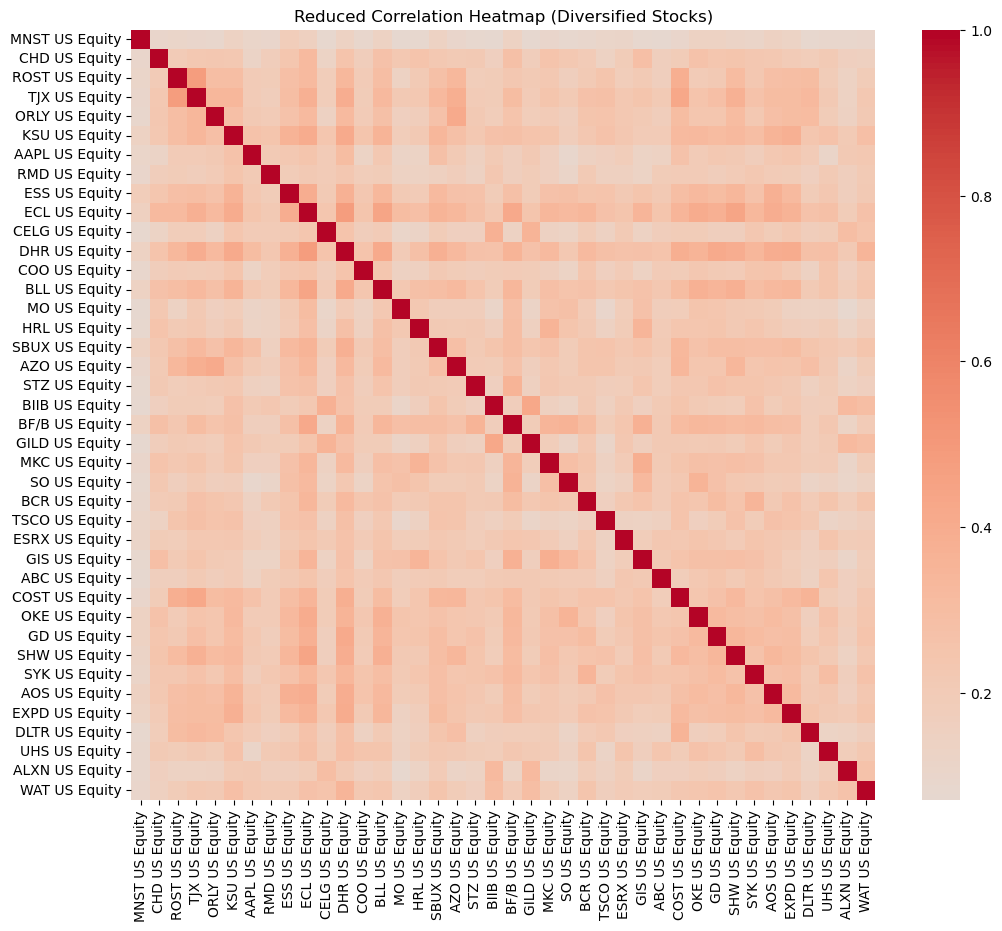

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,10))
sns.heatmap(reduced_corr, cmap='coolwarm', center=0)
plt.title("Reduced Correlation Heatmap (Diversified Stocks)")
plt.show()

## Plot Clustered Correlation Heatmap

Reorder the correlation matrix to make groups of similar-moving stocks easier to identify.

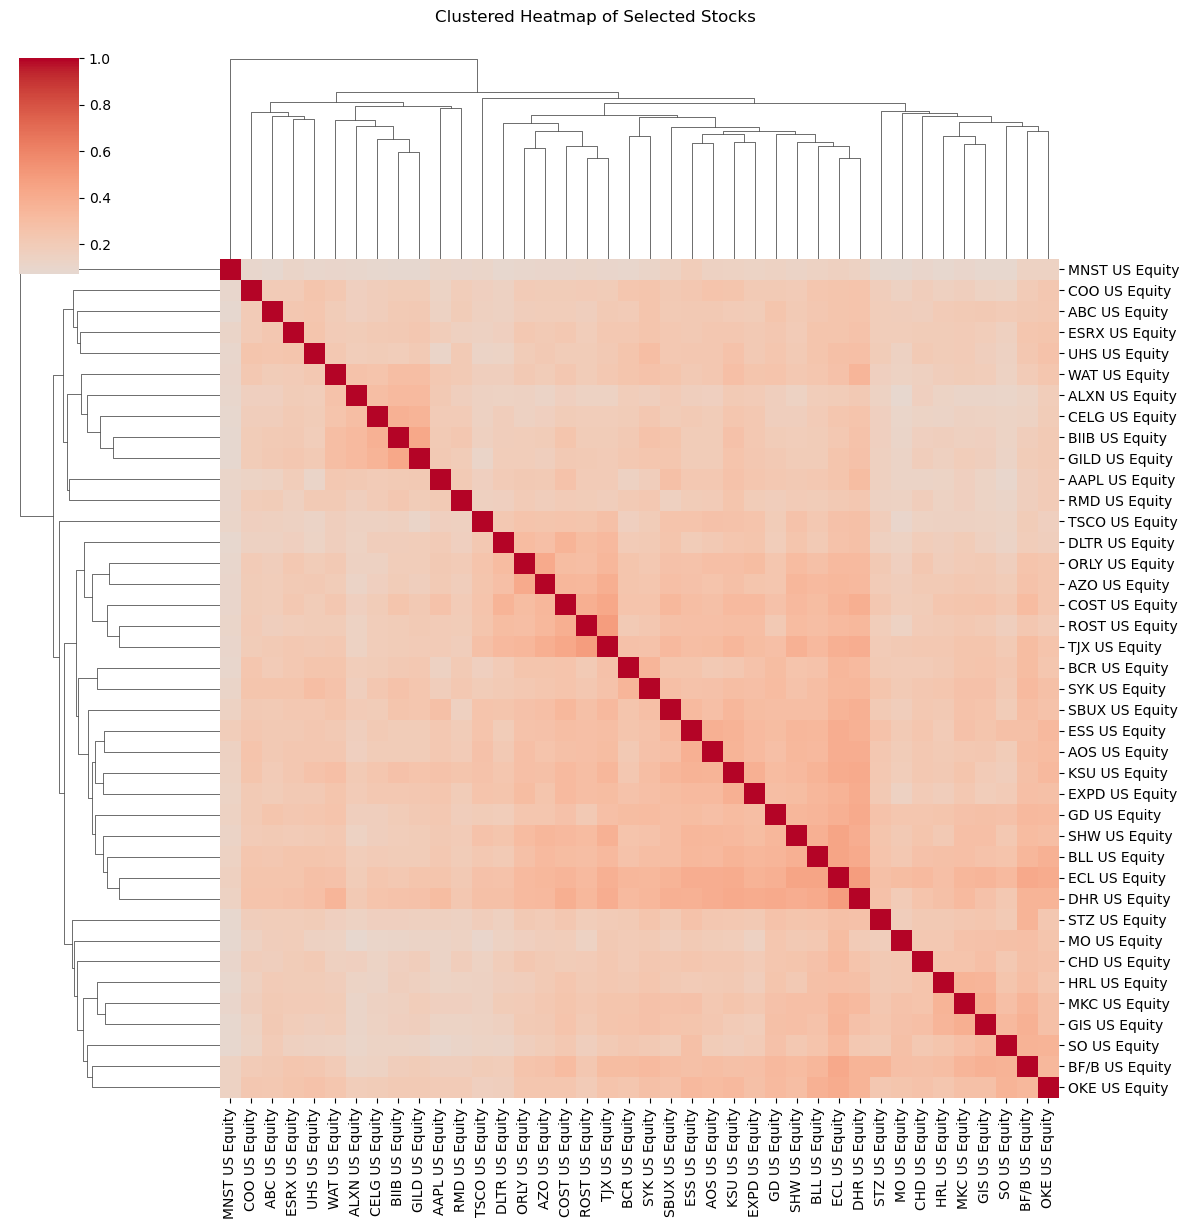

In [49]:
sns.clustermap(
    reduced_corr,
    cmap='coolwarm',
    center=0,
    figsize=(12,12)
)

plt.suptitle("Clustered Heatmap of Selected Stocks", y=1.02)
plt.show()

## Compare Average Correlation before and after Reduction

Check whether the stock reduction process lowered overall correlation and improved diversification.

In [52]:
print("Average correlation (original):", corr_matrix.values.mean())
print("Average correlation (reduced):", reduced_corr.values.mean())

Average correlation (original): 0.28367592376716955
Average correlation (reduced): 0.24830663676024634


## Create a Presentation-Friendly Correlation Heatmap

Use a smaller subset of selected stocks so the heatmap is readable in a presentation.

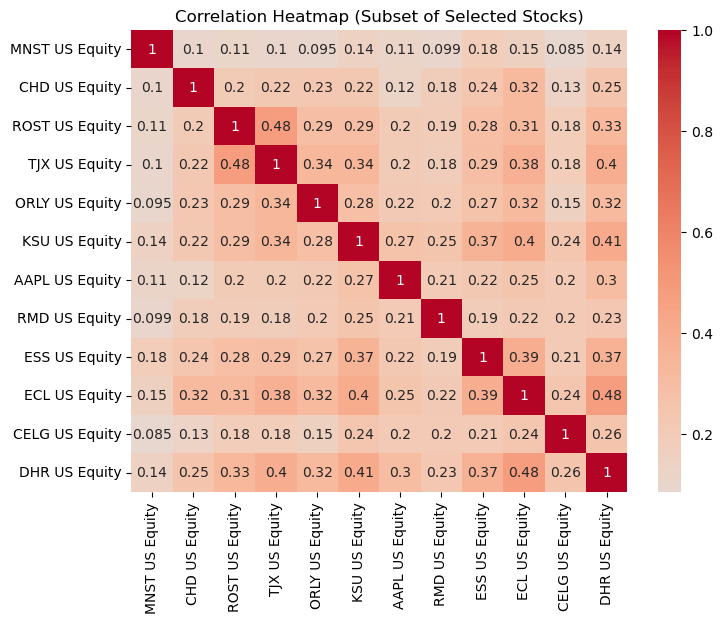

In [54]:
subset_stocks = selected_stocks[:12]

subset_corr = reduced_corr.loc[subset_stocks, subset_stocks]

plt.figure(figsize=(8,6))
sns.heatmap(subset_corr, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Heatmap (Subset of Selected Stocks)")
plt.savefig('heatmap.png',transparent = True)
plt.show()

## Convert the Reduced Correlation Matrix into Stock Pairs

Transform the matrix into a table so the highest and lowest correlated stock pairs can be inspected.

In [69]:
reduced_corr_pairs = reduced_corr.unstack().reset_index()
reduced_corr_pairs.columns = ['Stock_1', 'Stock_2', 'Correlation']

# remove self-correlations
reduced_corr_pairs = reduced_corr_pairs[
    reduced_corr_pairs['Stock_1'] != reduced_corr_pairs['Stock_2']
]

# remove duplicate pairs like (A,B) and (B,A)
reduced_corr_pairs['Pair'] = reduced_corr_pairs.apply(
    lambda x: tuple(sorted([x['Stock_1'], x['Stock_2']])),
    axis=1
)

reduced_corr_pairs = reduced_corr_pairs.drop_duplicates(subset='Pair').drop(columns='Pair')

## Display Highest and Lowest Correlated Stock Pairs

Show specific examples of strong and weak stock relationships in the reduced set.

In [71]:
high_corr_pairs = reduced_corr_pairs.sort_values(by='Correlation', ascending=False).head(10)
low_corr_pairs = reduced_corr_pairs.sort_values(by='Correlation', ascending=True).head(10)

print("Top 10 highest correlations:")
display(high_corr_pairs)

print("Top 10 lowest correlations:")
display(low_corr_pairs)

Top 10 highest correlations:


,Stock_1,Stock_2,Correlation
371,ECL US Equity,DHR US Equity,0.483724
83,ROST US Equity,TJX US Equity,0.482056
392,ECL US Equity,SHW US Equity,0.444500
373,ECL US Equity,BLL US Equity,0.440509
781,BIIB US Equity,GILD US Equity,0.428109
149,TJX US Equity,COST US Equity,0.424431
380,ECL US Equity,BF/B US Equity,0.420296
453,DHR US Equity,BLL US Equity,0.415688
211,KSU US Equity,DHR US Equity,0.411102
177,ORLY US Equity,AZO US Equity,0.409785


Top 10 lowest correlations:


,Stock_1,Stock_2,Correlation
28,MNST US Equity,ABC US Equity,0.071181
19,MNST US Equity,BIIB US Equity,0.071803
14,MNST US Equity,MO US Equity,0.072656
21,MNST US Equity,GILD US Equity,0.077763
36,MNST US Equity,DLTR US Equity,0.079467
598,MO US Equity,ALXN US Equity,0.080208
27,MNST US Equity,GIS US Equity,0.084664
10,MNST US Equity,CELG US Equity,0.084836
18,MNST US Equity,STZ US Equity,0.086770
23,MNST US Equity,SO US Equity,0.088119


## Plot the Distribution of Correlations

Compare the spread of correlations in the full and reduced datasets.

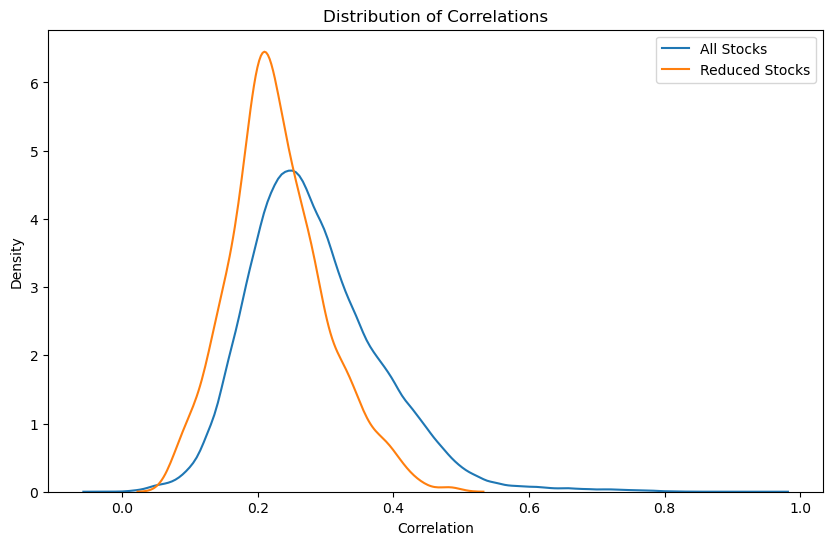

In [72]:
import seaborn as sns

# flatten correlations (exclude diagonal)
corr_values = corr_matrix.values.flatten()
corr_values = corr_values[corr_values < 0.999]

reduced_values = reduced_corr.values.flatten()
reduced_values = reduced_values[reduced_values < 0.999]

plt.figure(figsize=(10,6))

sns.kdeplot(corr_values, label="All Stocks")
sns.kdeplot(reduced_values, label="Reduced Stocks")

plt.title("Distribution of Correlations")
plt.xlabel("Correlation")
plt.legend()
plt.show()

## Build the Equal-Weight Portfolio Using All Stocks

Create the broad market baseline using all available stock returns.

In [73]:
# equal weight on ALL stocks
n_all = returns.shape[1]
weights_all = np.ones(n_all) / n_all

portfolio_returns_all = returns.dot(weights_all)
cum_returns_all = (1 + portfolio_returns_all).cumprod()

## Build the Equal-Weight Portfolio Using Reduced Stocks

Test whether the selected stock universe performs differently under equal weighting.

In [74]:
# equal weights
n = len(selected_stocks)
weights_equal = np.ones(n) / n

# portfolio returns
portfolio_returns_equal = reduced_returns.dot(weights_equal)

# cumulative return
cum_returns_equal = (1 + portfolio_returns_equal).cumprod()

## Build the Smart Portfolio Using Score-Based Weights

Assign higher weights to selected stocks with stronger return-to-volatility scores.

In [75]:
# get stats for selected stocks only
selected_stats = stock_stats.loc[selected_stocks]

# normalize scores → weights
weights_smart = selected_stats['Score'] / selected_stats['Score'].sum()

# portfolio returns
portfolio_returns_smart = reduced_returns.dot(weights_smart)

# cumulative
cum_returns_smart = (1 + portfolio_returns_smart).cumprod()

## Prepare Rolling Returns for the Dynamic Portfolio

Use recent performance signals while removing negative rolling values to avoid unstable negative weights.

In [76]:
rolling_return = reduced_returns.rolling(window=30).mean()

# remove negatives
rolling_return = rolling_return.clip(lower=0)

## Build the Dynamic Portfolio

Generate time-varying weights from rolling returns and calculate the dynamic portfolio performance.

In [77]:
weights_dynamic = rolling_return.div(rolling_return.sum(axis=1), axis=0)

# fill NaN (when all values were zero)
weights_dynamic = weights_dynamic.fillna(1 / len(selected_stocks))

portfolio_returns_dynamic = (weights_dynamic * reduced_returns).sum(axis=1)

cum_returns_dynamic = (1 + portfolio_returns_dynamic).cumprod()

## Plot Early Portfolio Comparison

Compare cumulative returns across the baseline, reduced, and smart portfolio strategies.

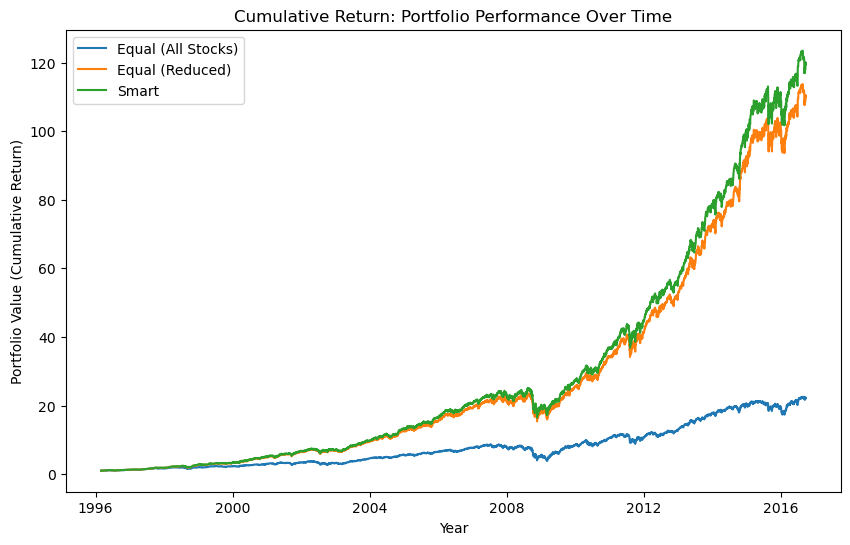

In [78]:
plt.figure(figsize=(10,6))

plt.plot(cum_returns_all, label="Equal (All Stocks)")
plt.plot(cum_returns_equal, label="Equal (Reduced)")
plt.plot(cum_returns_smart, label="Smart")

plt.title("Portfolio Comparison")
plt.ylabel("Portfolio Value (Cumulative Return)")
plt.xlabel("Year")
plt.title("Cumulative Return: Portfolio Performance Over Time")
plt.legend()
plt.savefig('cumulativereturn.png',transparent = True)
plt.show()

## Print Basic Portfolio Performance Statistics

Summarise mean return, volatility, and Sharpe ratio for the early portfolio strategies.

In [79]:
def portfolio_stats(returns):
    return {
        "Mean Return": returns.mean(),
        "Volatility": returns.std(),
        "Sharpe (proxy)": returns.mean() / returns.std()
    }

print("Equal - All:", portfolio_stats(portfolio_returns_all))
print("Equal - Reduced:", portfolio_stats(portfolio_returns_equal))
print("Smart:", portfolio_stats(portfolio_returns_smart))
print("Dynamic:", portfolio_stats(portfolio_returns_dynamic))

Equal - All: {'Mean Return': 0.0006826333159316143, 'Volatility': 0.01291744974359951, 'Sharpe (proxy)': 0.0528458271161344}
Equal - Reduced: {'Mean Return': 0.0009660132572943149, 'Volatility': 0.010770941702545282, 'Sharpe (proxy)': 0.08968698225021832}
Smart: {'Mean Return': 0.00098220423397902, 'Volatility': 0.010791577002371357, 'Sharpe (proxy)': 0.09101582037205395}
Dynamic: {'Mean Return': 0.004839372436323673, 'Volatility': 0.014317172667541136, 'Sharpe (proxy)': 0.33801173937750645}


## Recalculate Daily Stock Returns

Create the returns matrix used for correlation analysis, portfolio construction, and risk measurement.

In [80]:
returns = df_cleaned.iloc[:, 1:].pct_change().dropna()
corr_matrix = returns.corr()
corr_matrix.head()

,AAPL US Equity,ABC US Equity,ABMD US Equity,ABT US Equity,ABX US Equity,ADBE US Equity,ADI US Equity,ADM US Equity,ADP US Equity,ADSK US Equity,...,WY US Equity,X US Equity,XEL US Equity,XL US Equity,XLNX US Equity,XOM US Equity,XRAY US Equity,XRX US Equity,YRCW US Equity,ZION US Equity
AAPL US Equity,1.000000,0.137694,0.154638,0.157424,0.040033,0.346338,0.378960,0.178059,0.277101,0.302428,...,0.234390,0.242596,0.119792,0.205498,0.395956,0.219030,0.187827,0.256048,0.126897,0.208060
ABC US Equity,0.137694,1.000000,0.103472,0.253852,0.040797,0.203265,0.168231,0.199252,0.230121,0.180756,...,0.214104,0.194844,0.155513,0.189364,0.139560,0.236184,0.238990,0.174436,0.091987,0.183842
ABMD US Equity,0.154638,0.103472,1.000000,0.149622,0.018723,0.212236,0.211020,0.145357,0.185346,0.190949,...,0.198128,0.170475,0.104889,0.181352,0.197042,0.174154,0.185628,0.147750,0.083953,0.202997
ABT US Equity,0.157424,0.253852,0.149622,1.000000,0.047792,0.197503,0.184926,0.259817,0.342371,0.195881,...,0.268474,0.209141,0.264384,0.236403,0.190539,0.349529,0.301306,0.201141,0.101765,0.218204
ABX US Equity,0.040033,0.040797,0.018723,0.047792,1.000000,0.030737,0.036841,0.155367,0.079178,0.061048,...,0.146050,0.265847,0.104467,0.041376,0.035611,0.231099,0.090737,0.079865,0.057943,0.045333


## Calculate Average Correlation per Stock

Remove self-correlation and measure how strongly each stock moves with the rest of the market.

In [81]:
corr_no_diag = corr_matrix.copy()
np.fill_diagonal(corr_no_diag.values, np.nan)

avg_corr = corr_no_diag.mean()
avg_corr.head()

AAPL US Equity    0.219604
ABC US Equity     0.195313
ABMD US Equity    0.169459
ABT US Equity     0.239644
ABX US Equity     0.093517
dtype: float64

## Build Specialist Portfolio Weights

Assign larger weights to stocks with higher average correlation.

In [83]:
weights_specialist = avg_corr / avg_corr.sum()
weights_specialist.head()

AAPL US Equity    0.001711
ABC US Equity     0.001522
ABMD US Equity    0.001320
ABT US Equity     0.001867
ABX US Equity     0.000729
dtype: float64

## Validate Specialist Portfolio Weights

Check that the Specialist weights sum to one and do not contain unusual values.

In [84]:
print("Sum of Specialist weights:", weights_specialist.sum())
print("Minimum weight:", weights_specialist.min())
print("Maximum weight:", weights_specialist.max())

Sum of Specialist weights: 1.0
Minimum weight: 0.000728580621130068
Maximum weight: 0.0031182180133722845


## Calculate Specialist Portfolio Returns

Apply the Specialist weights to the full return dataset.

In [85]:
portfolio_specialist = returns.dot(weights_specialist)
portfolio_specialist.head()

Date
1996-02-29   -0.005764
1996-03-01    0.000801
1996-03-04    0.011884
1996-03-05    0.005092
1996-03-06   -0.000612
dtype: float64

## Calculate Specialist Cumulative Return

Convert daily Specialist returns into cumulative portfolio growth over time.

In [87]:
cum_specialist = (1 + portfolio_specialist).cumprod()
cum_specialist.head()

Date
1996-02-29    0.994236
1996-03-01    0.995033
1996-03-04    1.006857
1996-03-05    1.011984
1996-03-06    1.011365
dtype: float64

## Plot Specialist Portfolio Performance

Visualise how the Specialist strategy performs across the full investment period.

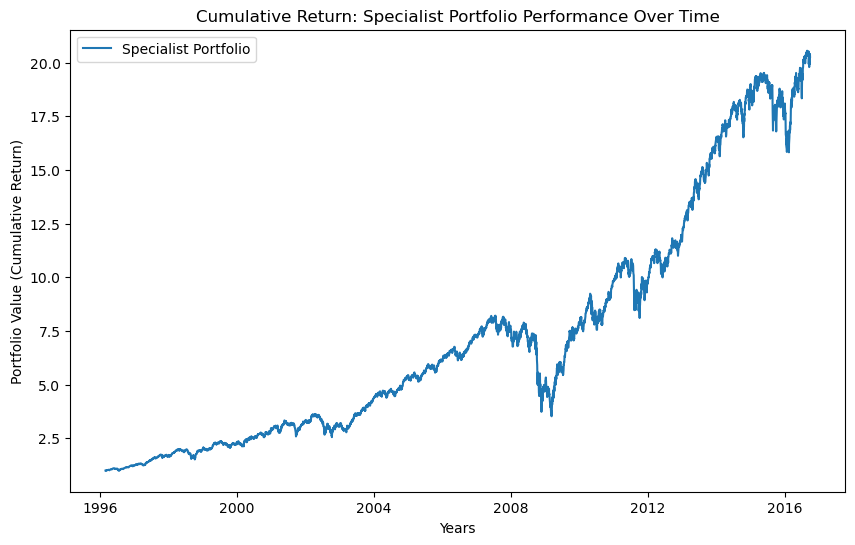

In [88]:
plt.figure(figsize=(10,6))
plt.plot(cum_specialist, label="Specialist Portfolio")

plt.xlabel("Years")
plt.ylabel("Portfolio Value (Cumulative Return)")
plt.title("Cumulative Return: Specialist Portfolio Performance Over Time")
plt.legend()
plt.savefig('specialist.png',transparent = True)
plt.show()

## Recalculate Cumulative Returns for Final Comparison

Prepare cumulative return series for all main portfolios before plotting final results.

In [89]:
cum_returns_all = (1 + portfolio_returns_all).cumprod()
cum_returns_equal = (1 + portfolio_returns_equal).cumprod()
cum_returns_smart = (1 + portfolio_returns_smart).cumprod()
cum_specialist = (1 + portfolio_specialist).cumprod()

## Recalculate Cumulative Returns for Final Comparison

Prepare cumulative return series for all main portfolios before plotting final results.

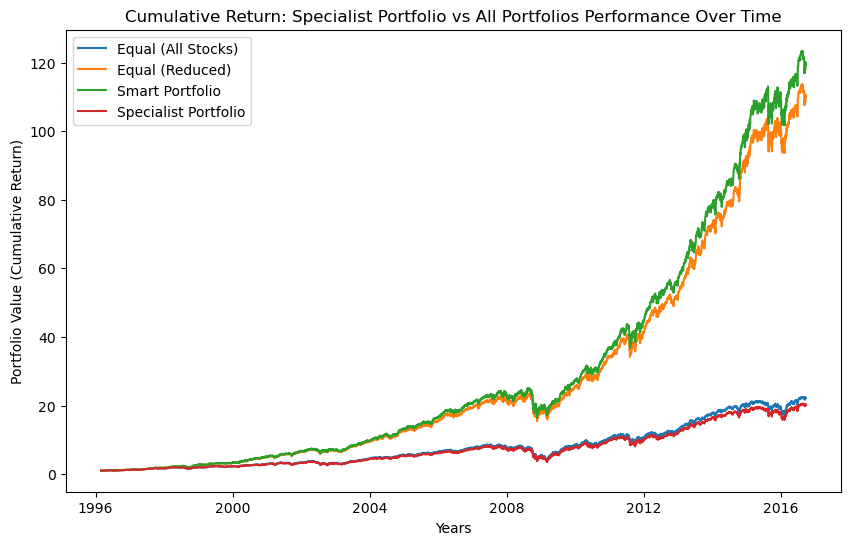

In [90]:
plt.figure(figsize=(10,6))

plt.plot(cum_returns_all, label="Equal (All Stocks)")
plt.plot(cum_returns_equal, label="Equal (Reduced)")
plt.plot(cum_returns_smart, label="Smart Portfolio")
plt.plot(cum_specialist, label="Specialist Portfolio")

plt.xlabel("Years")
plt.ylabel("Portfolio Value (Cumulative Return)")
plt.title("Cumulative Return: Specialist Portfolio vs All Portfolios Performance Over Time")
plt.legend()
plt.savefig('total.png',transparent = True)
plt.show()

## Build Final Portfolio Statistics Table

Calculate return, volatility, and Sharpe ratio for each main portfolio.

In [91]:
stats_df = pd.DataFrame({
    "Portfolio": [
        "Equal-All",
        "Equal-Reduced",
        "Smart",
        "Specialist",
    ],
    "Return": [
        portfolio_returns_all.mean(),
        portfolio_returns_equal.mean(),
        portfolio_returns_smart.mean(),
        portfolio_specialist.mean(),
    ],
    "Volatility": [
        portfolio_returns_all.std(),
        portfolio_returns_equal.std(),
        portfolio_returns_smart.std(),
        portfolio_specialist.std(),
    ]
})

stats_df["Sharpe"] = stats_df["Return"] / stats_df["Volatility"]
stats_df = stats_df.round(6)

stats_df

,Portfolio,Return,Volatility,Sharpe
0,Equal-All,0.000683,0.012917,0.052846
1,Equal-Reduced,0.000966,0.010771,0.089687
2,Smart,0.000982,0.010792,0.091016
3,Specialist,0.000669,0.013235,0.050542


## Plot Risk-Return Trade-Off

Show how each portfolio balances average return against volatility.

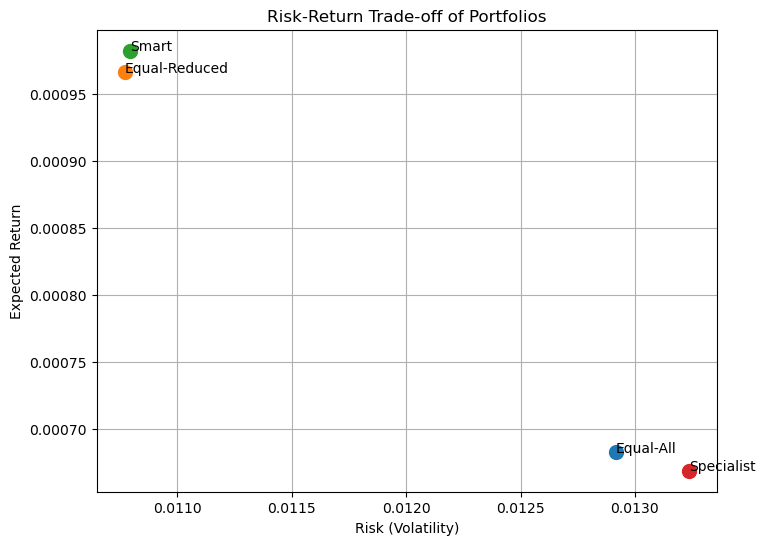

In [93]:
plt.figure(figsize=(8,6))

for _, row in stats_df.iterrows():
    plt.scatter(row["Volatility"], row["Return"], s=100)
    plt.text(row["Volatility"], row["Return"], row["Portfolio"])

plt.xlabel("Risk (Volatility)")
plt.ylabel("Expected Return")
plt.title("Risk-Return Trade-off of Portfolios")
plt.grid(True)
plt.savefig('risk.png',transparent = True)
plt.show()

## Calculate Annualised Return and Risk Metrics

Estimate annualised performance statistics for the selected portfolio strategies.

In [129]:
portfolios = pd.DataFrame({
    "Equal": portfolio_returns_equal,
    "Smart": portfolio_returns_smart,
    "Specialist": portfolio_specialist
})

# Annualised return (approx 252 trading days)
annual_return = portfolios.mean() * 252

# Annualised volatility
annual_volatility = portfolios.std() * np.sqrt(252)

# Combine into one table
stats_df = pd.DataFrame({
    "Return": annual_return,
    "Volatility": annual_volatility
})

print(stats_df)

              Return  Volatility
Equal       0.243435    0.170983
Smart       0.247515    0.171311
Specialist  0.168568    0.210098


## Define Full Portfolio Summary Function

Create a reusable function for total cumulative return, volatility, and Sharpe ratio.

In [131]:
def portfolio_summary(portfolio_returns):
    cumulative_return_series = (1 + portfolio_returns).cumprod()

    final_cumulative_value = cumulative_return_series.iloc[-1]
    total_return_percent = (final_cumulative_value - 1) * 100

    mean_daily_return = portfolio_returns.mean()
    standard_deviation = portfolio_returns.std() * np.sqrt(252)
    volatility = standard_deviation
    sharpe = mean_daily_return / standard_deviation

    return {
        "Final Cumulative Value": final_cumulative_value,
        "Total Return (%)": total_return_percent,
        "Mean Daily Return": mean_daily_return,
        "Standard Deviation": standard_deviation,
        "Volatility (Risk)": volatility,
        "Sharpe": sharpe
    }

## Generate Final Portfolio Summary Table

Apply the summary function to all main portfolios for final comparison.

In [132]:
summary_df = pd.DataFrame({
    "Equal-All": portfolio_summary(portfolio_returns_all),
    "Equal-Reduced": portfolio_summary(portfolio_returns_equal),
    "Smart": portfolio_summary(portfolio_returns_smart),
    "Specialist": portfolio_summary(portfolio_specialist)
}).T

summary_df.round(6)

,Final Cumulative Value,Total Return (%),Mean Daily Return,Standard Deviation,Volatility (Risk),Sharpe
Equal-All,22.238059,2123.805852,0.000683,0.205058,0.205058,0.003329
Equal-Reduced,110.011231,10901.123126,0.000966,0.170983,0.170983,0.005650
Smart,119.484599,11848.459926,0.000982,0.171311,0.171311,0.005733
Specialist,20.274255,1927.425493,0.000669,0.210098,0.210098,0.003184


## Calculate and Plot Portfolio Drawdowns

Measure how far the Specialist and Smart portfolios fall from previous peaks during downturns.

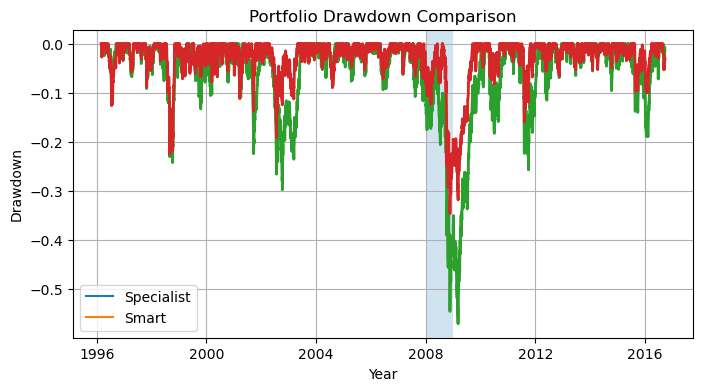

In [146]:
# Drawdown calculation
drawdown_specialist = (
    cum_specialist / cum_specialist.cummax()
) - 1

drawdown_smart = (
    cum_returns_smart / cum_returns_smart.cummax()
) - 1

# Plot
plt.figure(figsize=(8,4))

plt.plot(
    drawdown_specialist,
    label="Specialist"
)

plt.plot(
    drawdown_smart,
    label="Smart"
)

plt.title("Portfolio Drawdown Comparison")
plt.xlabel("Year")
plt.ylabel("Drawdown")

plt.legend()
plt.grid(True)

plt.savefig('cum.png',transparent = True)
plt.plot(drawdown_specialist, label="Specialist", linewidth=2)
plt.plot(drawdown_smart, label="Smart", linewidth=2)
plt.axvspan('2008', '2009', alpha=0.2)
plt.show()